# Exploratory Data Analysis — Expected Threat Model

Analysis of StatsBomb event data (5 top European leagues, 2015/16 season).

In [1]:
%load_ext autoreload
%autoreload 2

import eda
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120

df = eda.load_raw()
print(f"Loaded {len(df):,} events, {df['match_id'].nunique()} matches")
print(f"Possessions: {df.groupby(['match_id','possession']).ngroups:,}")

Loaded 6,391,338 events, 1823 matches
Possessions: 356,284


## 1. Data Completeness (Nulls)

Null analysis for columns relevant to the model — both overall and scoped to the event types where each column should be populated.

In [2]:
print("Overall null counts:")
display(eda.null_analysis(df))

print("\nNull rates scoped to relevant event types:")
display(eda.null_analysis_by_type(df))

Overall null counts:


,column,non_null,null,null_pct
0,type,6391338,0,0.00
1,location,6346168,45170,0.71
2,pass_end_location,1777412,4613926,72.19
3,carry_end_location,1334386,5056952,79.12
4,shot_outcome,45719,6345619,99.28
5,possession,6391338,0,0.00
6,team,6391338,0,0.00
7,possession_team,6391338,0,0.00
8,match_id,6391338,0,0.00



Null rates scoped to relevant event types:


,column,scope,total,null,null_pct
0,location,All events,6391338,45170,0.7067
1,pass_end_location,Pass events,1777412,0,0.0000
2,carry_end_location,Carry events,1334386,0,0.0000
3,shot_outcome,Shot events,45719,0,0.0000


## 2. Event Type Distribution

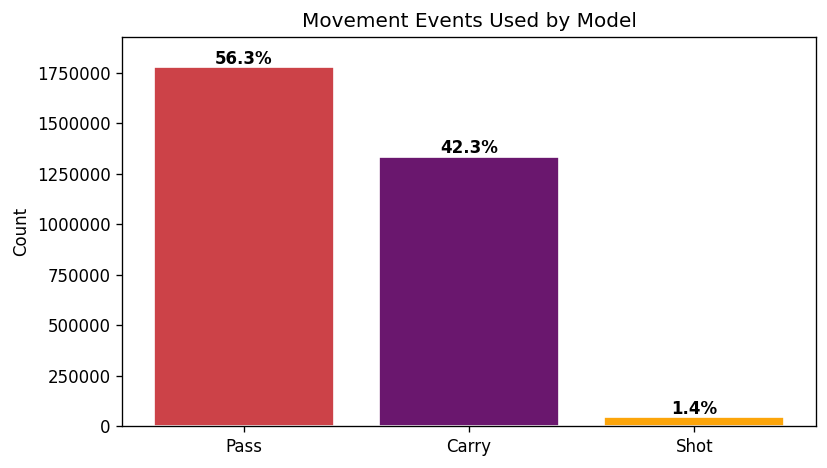

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
eda.plot_movement_event_distribution(df, ax=ax)
plt.tight_layout()
fig.savefig("EDA_figures/event_type_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Possession Chain Lengths

Raw chain lengths before any truncation — movement events only (Pass, Carry, Shot).

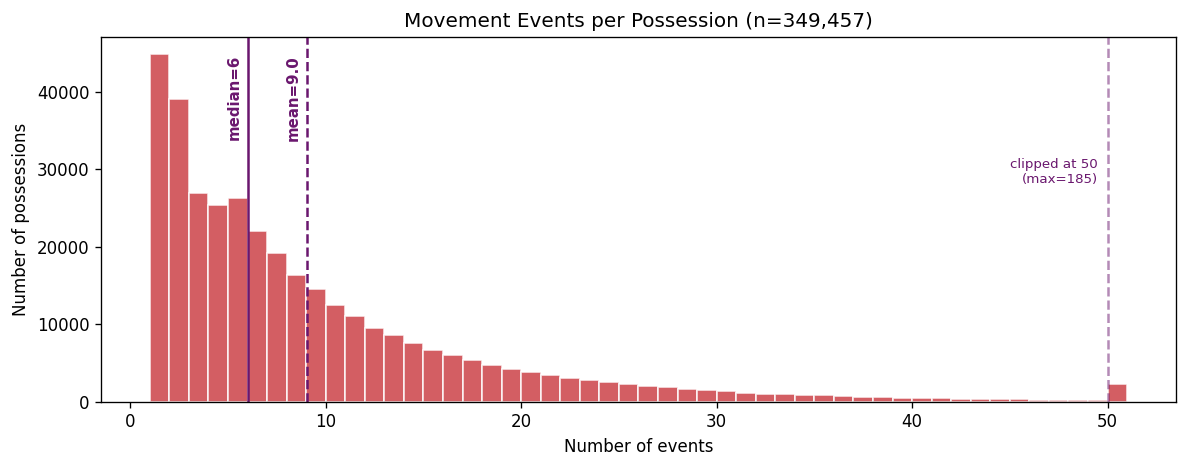

In [4]:
lengths_move = eda.compute_possession_lengths(df, movement_only=True)

fig, ax = plt.subplots(figsize=(10, 4))
eda.plot_possession_length_distribution(lengths_move, title="Movement Events per Possession", ax=ax)
plt.tight_layout()
fig.savefig("EDA_figures/possession_chain_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

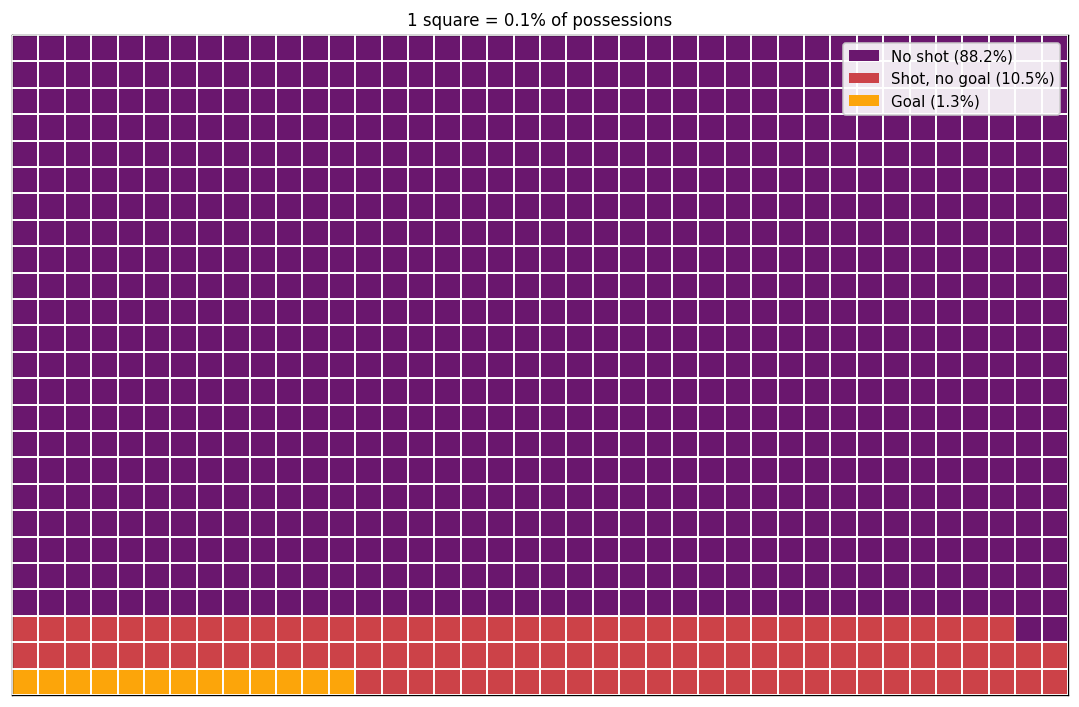

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
eda.plot_shot_goal_waffle(df, ax=ax, cols=40, rows=25)
plt.tight_layout()
fig.savefig("EDA_figures/shot_goal_waffle.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Pass and Carry Distances

Euclidean distance distributions. For carries, vertical lines mark the thresholds tested in Phase 1.

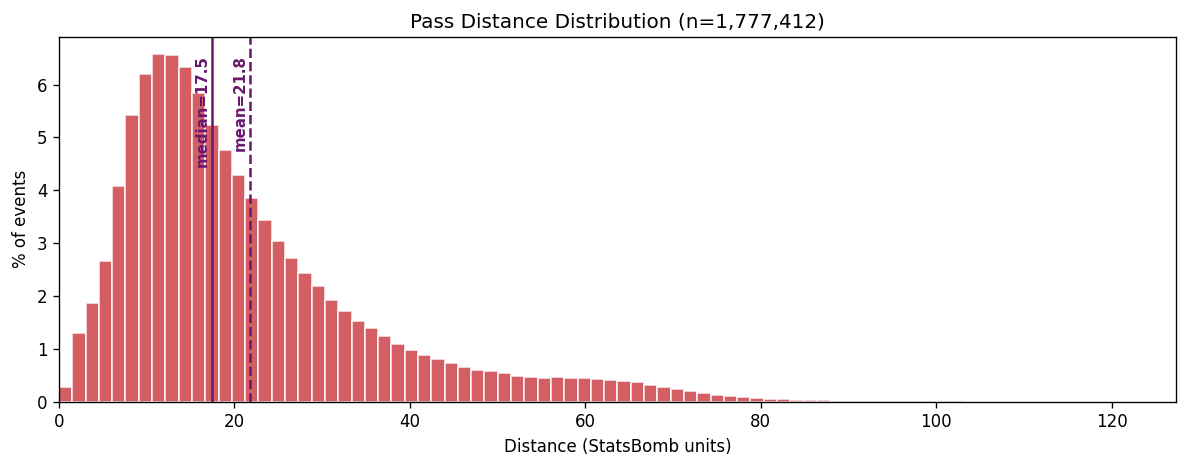

In [6]:
distances = eda.compute_distances(df)

fig, ax = plt.subplots(figsize=(10, 4))
eda.plot_distance_distribution(distances, event_type="Pass", ax=ax)
plt.tight_layout()
fig.savefig("EDA_figures/pass_distance_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

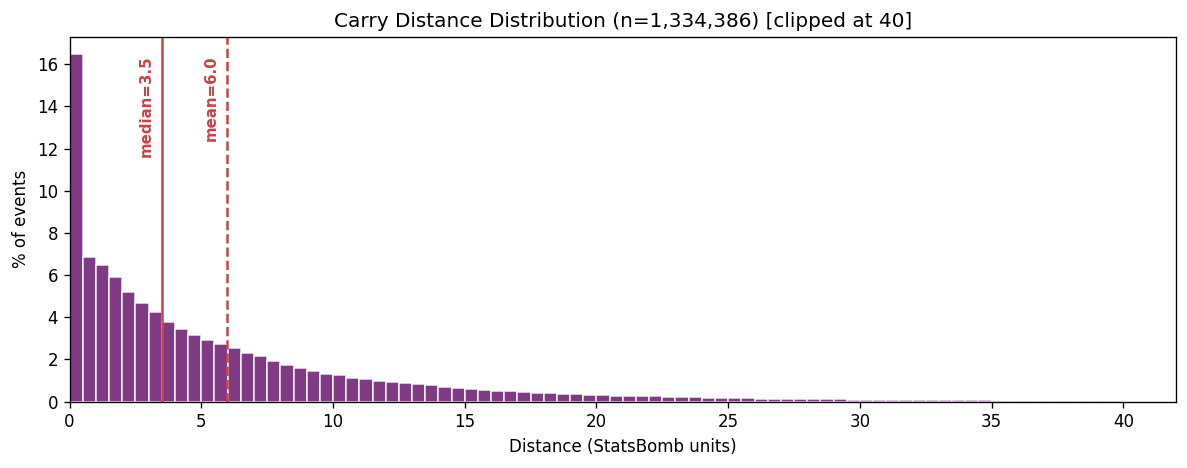

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
eda.plot_distance_distribution(distances, event_type="Carry", clip=40, ax=ax)
plt.tight_layout()
fig.savefig("EDA_figures/carry_distance_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Carry threshold summary table
display(eda.carry_threshold_summary(distances))

,threshold,carries_remaining,pct_remaining,carries_removed,pct_removed
0,1,1023437,76.7,310949,23.3
1,2,857909,64.3,476477,35.7
2,3,726029,54.4,608357,45.6
3,5,531098,39.8,803288,60.2
4,8,336302,25.2,998084,74.8


## 5. Shot Rate by Pitch Zone

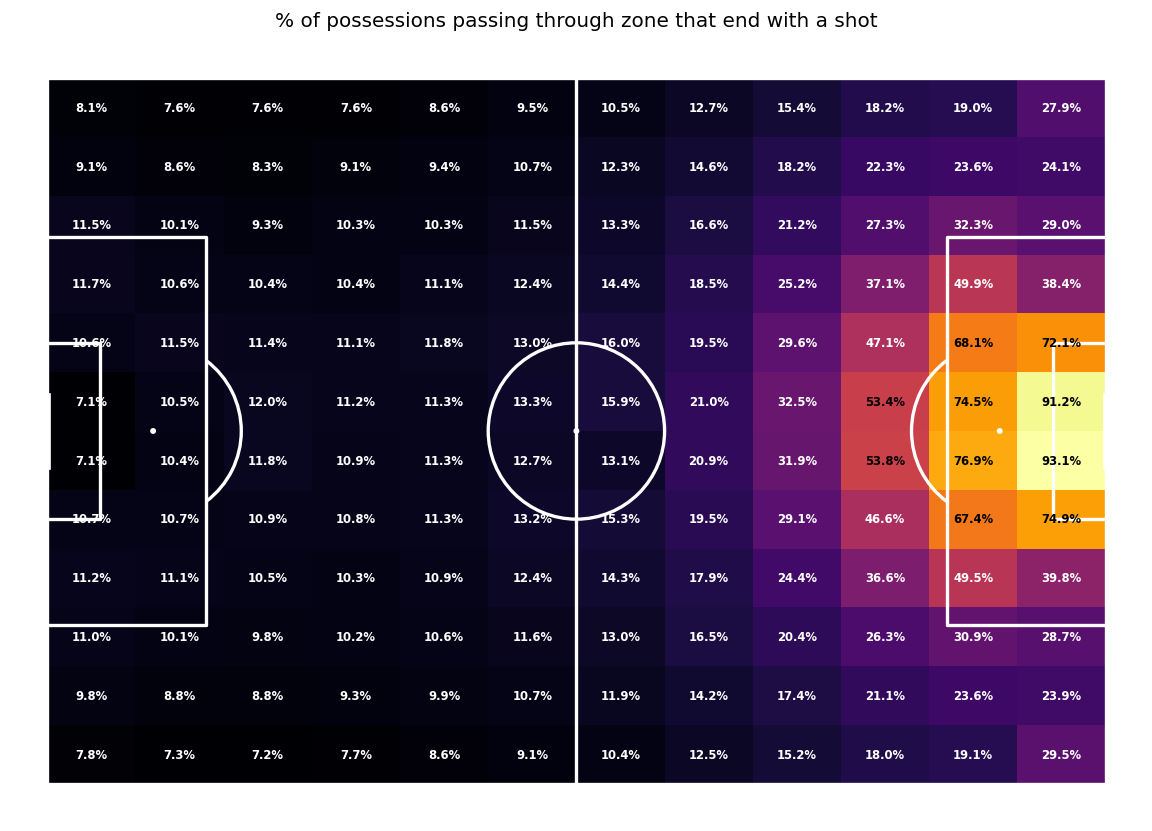

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
eda.plot_shot_rate_heatmap(df, ax=ax)
plt.tight_layout()
fig.savefig("EDA_figures/shot_rate_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()